In [1]:
!pip install lightgbm

In [2]:
# 라이브러리
import pandas as pd
import numpy as np
import os
import lightgbm as lgb

In [3]:
# 1. 데이터 경로
data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_kakr_housing/data')

train_path = os.path.join(data_dir, 'train.csv')
test_path = os.path.join(data_dir, 'test.csv')

In [4]:
# 2. 데이터 불러오기
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("데이터 로드 완료")
print(train.shape)


데이터 로드 완료
(15035, 21)


In [5]:
# 3. 정답값 (로그 변환)
y = np.log1p(train['price'])

In [6]:
# 4. 입력 데이터
X = train.drop(['price'], axis=1)

In [7]:
# 5. id 제거
if 'id' in X.columns:
    X = X.drop(['id'], axis=1)

if 'id' in test.columns:
    test_id = test['id']
    test = test.drop(['id'], axis=1)
else:
    test_id = test.index

In [8]:

# 6. date 제거
if 'date' in X.columns:
    X = X.drop(['date'], axis=1)

if 'date' in test.columns:
    test = test.drop(['date'], axis=1)

In [9]:
# 7. 결측치 처리
X = X.fillna(0)
test = test.fillna(0)

In [10]:

# 8. 모델 (LightGBM)
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

In [11]:
# 9. 학습
model.fit(X, y)

print("모델 학습 완료")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 18
[LightGBM] [Info] Start training from score 13.048122
모델 학습 완료


In [12]:
# 10. 예측
pred = model.predict(test)

In [13]:
# 11. 로그 되돌리기
pred = np.expm1(pred)

In [14]:
# 12. 제출 파일
submission = pd.DataFrame({
    'id': test_id,
    'price': pred
})

submission.to_csv('submission.csv', index=False)

print("제출 파일 생성 완료!")

제출 파일 생성 완료!


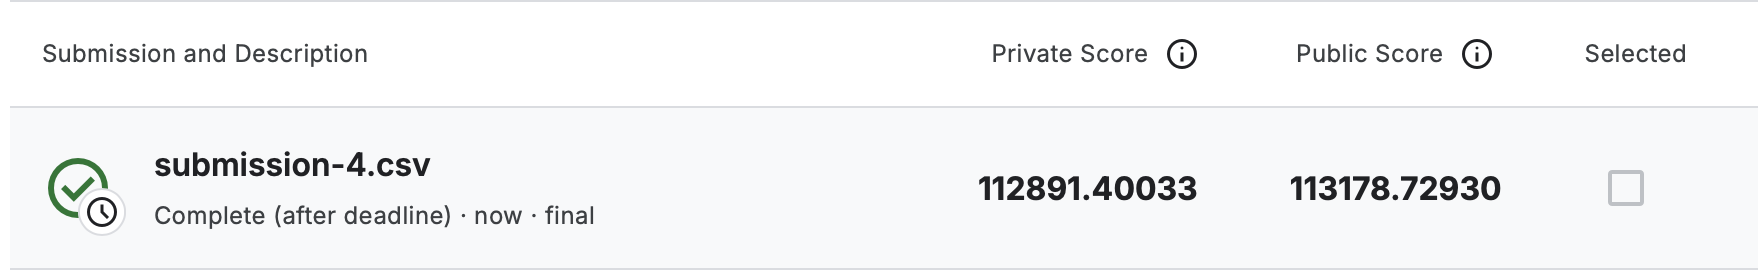